# <center>Project 1 2026</center>

<center>Author: Lewei Xu (23709058)</center>

In this project, we will deal with a small colour image dataset containing 10 classes, each image is 64 x 64 x 3 pixels. The training set, validation set, and test set are perfectly balanced, but only 370 training instances are available in each class. In this project, we will:

1. Train a CNN model including hyperparameter tuning. (Section 2)
2. Retrain a pretained NASNetMobile model. (Section 3)
3. Compare these 2 models. (Section 4)

## Section 1: Setup and Preprocessing

### Section 1.1: Imports and Data Loading

First, we will make the required imports and set configurations that will be used throughout the project.

In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from IPython.display import display
import time

np.random.seed(42)
tf.random.set_seed(42)

CNN_FILE = "Xu_Lewei-CNN.keras"
NASNET_FILE = "Xu_Lewei-NASNetMobile.keras"
TUNING_DIR = "cnn_tuning"

The 3 .pkl files store their contents using byte string keys. We will load them using the code provided by the project spec, and verify the shapes.

In [15]:
def load_data(pickle_file):
    import pickle
    with open(pickle_file, "rb") as f:
        dict = pickle.load(f)
    return dict[b"data"], dict[b"labels"], dict[b"class_names"]

X_train, y_train, class_names = load_data("./train-2026.pkl")
X_valid, y_valid, _ = load_data("./valid-2026.pkl")
X_test, y_test, _ = load_data("./test-2026.pkl")

# Check the shapes of the datasets and the data type and range of the training data
print("train:", X_train.shape, y_train.shape)
print("valid:", X_valid.shape, y_valid.shape)
print("test: ", X_test.shape, y_test.shape)
print("dtype:", X_train.dtype, "range:", X_train.min(), X_train.max())

train: (3700, 64, 64, 3) (3700,)
valid: (800, 64, 64, 3) (800,)
test:  (500, 64, 64, 3) (500,)
dtype: uint8 range: 0 255


In [16]:
print("Class names:", class_names)
n_classes = len(class_names)
pd.DataFrame({
    "train": np.bincount(y_train, minlength=n_classes),
    "valid": np.bincount(y_valid, minlength=n_classes),
    "test": np.bincount(y_test, minlength=n_classes),
}, index=class_names)

Class names: ['alligator', 'dragonfly', 'dugong', 'goldfish', 'goose', 'koala', 'scorpion', 'slug', 'snail', 'tarantula']


,train,valid,test
alligator,370,80,50
dragonfly,370,80,50
dugong,370,80,50
goldfish,370,80,50
goose,370,80,50
koala,370,80,50
scorpion,370,80,50
slug,370,80,50
snail,370,80,50
tarantula,370,80,50


Here we can see that the training set consists of 370 training instances per class across 10 classes, as specified by the project spec.

### Section 1.2: Data Exploration

We will now write a function ``display_images`` that samples images at random. The optional `indices`, `y_pred` and `title` arguments allow us to reuse it for the Comparisons section of our CNN models later on.

In [17]:
def display_images(X, y, class_names, n_images=30, n_cols=10, indices=None, y_pred=None, title=None, seed=42):

    # Get random indices if not provided
    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(len(X), size=min(n_images, len(X)), replace=False)
    indices = np.asarray(indices)[:n_images]

    # Display images
    n_rows = int(np.ceil(len(indices) / n_cols))
    plt.figure(figsize=(n_cols * 1.4, n_rows * 1.8))
    for i, index in enumerate(indices):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X[index])
        plt.axis("off")
        if y_pred is None:
            plt.title(class_names[y[index]], fontsize=9)
        else:
            plt.title(f"{class_names[y[index]]} -> {class_names[y_pred[index]]}", fontsize=8)
    if title is not None:
        plt.suptitle(title, y=1.0)
    plt.tight_layout()
    plt.show()

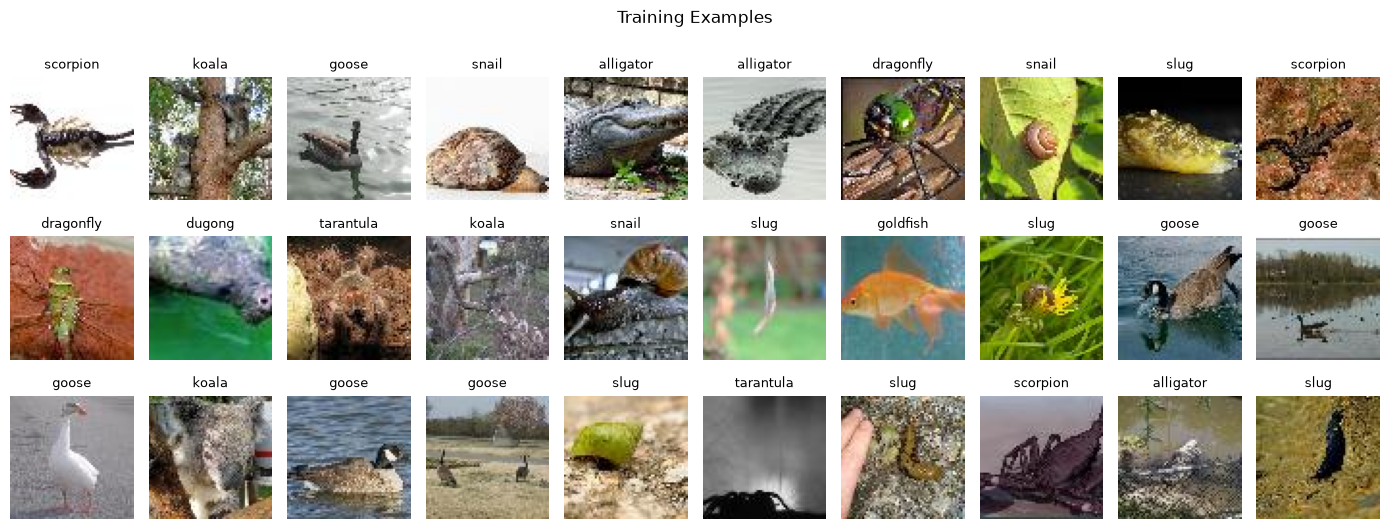

In [18]:
display_images(X_train, y_train, class_names, title="Training Examples")

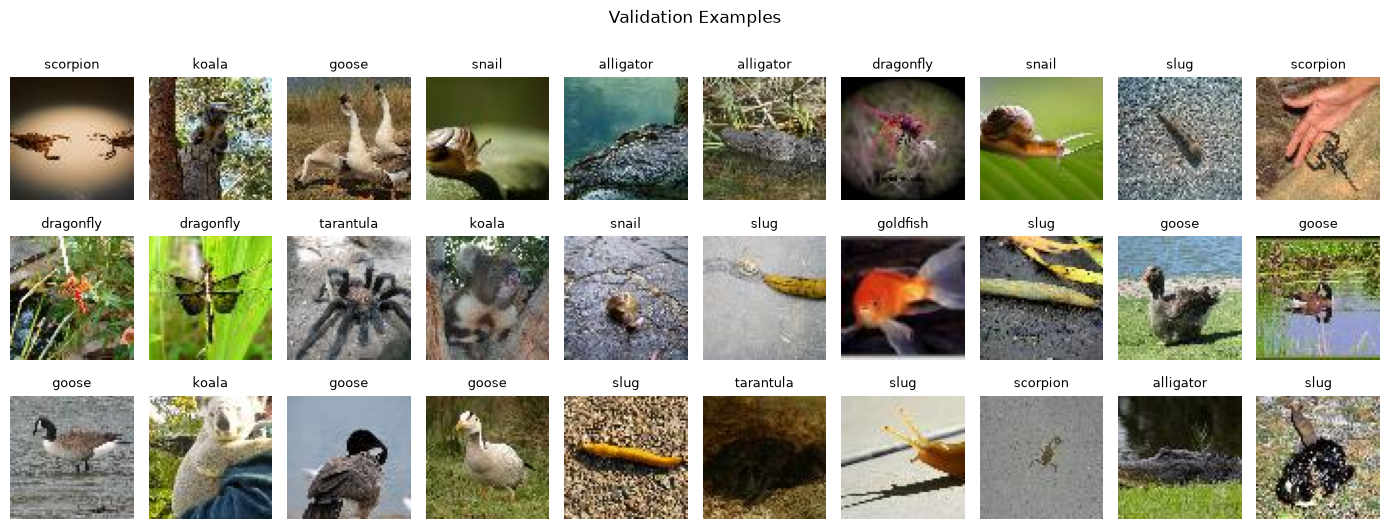

In [19]:
display_images(X_valid, y_valid, class_names, title="Validation Examples")

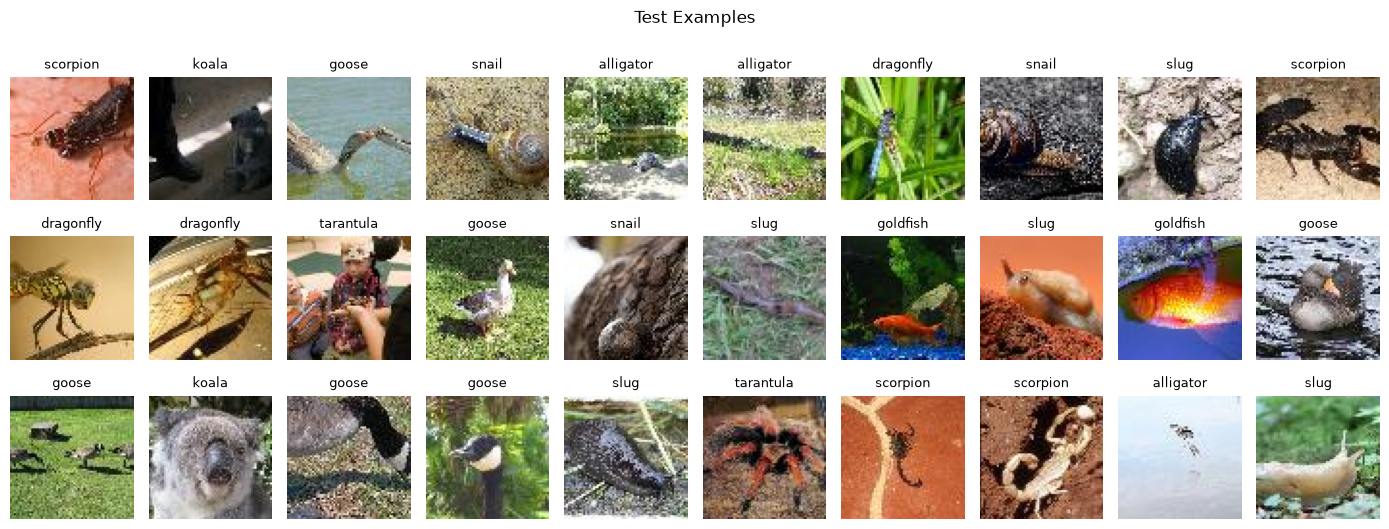

In [20]:
display_images(X_test, y_test, class_names, title="Test Examples")

Here we can see that the images are small and quite varied. Animals appear at different sizes within the image and vary in orientation, with various backgrounds within the same class. Colour pallettes between different classes also overlap, making this a very had problem.

### Section 1.3: Preprocessing

Training instances are stored in increasing classID order, so we must shuffle the training set before it is used, otherwise the mini batches would each contain mostly a single class causing the training to be unstable.

No need to scale the pixel range as this will be done in each model's ``Rescaling`` layer. This additionally allows the models to handle raw images at prediction time.

In [21]:
rng = np.random.default_rng(42)

train_order = rng.permutation(len(X_train))
X_train, y_train = X_train[train_order], y_train[train_order]

print("First 20 training labels after shuffling:", y_train[:20])

First 20 training labels after shuffling: [8 4 6 6 5 6 1 8 5 1 2 2 7 3 3 6 8 7 7 7]


## Section 2: CNN Model and Hyperparameter Tuning

Now that all our setup and preprocessing is done, we will now design and train a CNN model for this animal classification task.

### Section 2.1: Design CNN Model with Hyperparameter Tuning

First, we will define our CNN model design with hyperparameter tuning. The networks consists of (in the following order):
1. A 64 x 64 x 3 input layer
2. A Rescaling layer to scale inputs between 0-1
3. 4 convolutional layers, with 4 pooling layers after each convolutional layer
4. A global average pooling layer before the parameter heavy dense layer
5. A dropout layer
6. A single dense layer
7. Finally, a 10 way softmax output layer

In addition, we will insert 2 augmentation layers, a random horizontal flipping layer and a random rotation layer, before the convolution layers to assist with training and possibly increase performance. This allows us to artificially increase the size of the training set which is currently somewhat small, and apply some regularization to the model and make it more tolerant variations in position and orientation.

The ranges of the 6 tuned hyperparameters have been chosen so that every combination of the search space stays under 30 000 trainable parameters, with the worst case being 38 354 parameters.

We will use ReLU activations for all layers with He initialization as required, with Nadam optimizer.

In [22]:
def build_cnn_model(hp):
    # Hyperparameter choices for the CNN model
    # In the worst case, the parameter count will still stay under 30 000 parameters (28 354 params)
    filters1 = hp.Choice("filters1", [8, 12, 16])
    filters2 = hp.Choice("filters2", [16, 24, 32])
    filters3 = hp.Choice("filters3", [24, 32])
    filters4 = hp.Choice("filters4", [32, 40])
    dropout_rate = hp.Float("dropout_rate", 0.2, 0.5, step=0.1)
    n_units = hp.Choice("n_units", [16, 32, 48])

    tf.random.set_seed(42) # Set seed again for reproducibility

    # Define the CNN model architecture
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=[64, 64, 3]),
        tf.keras.layers.Rescaling(1. / 255),

        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),

        tf.keras.layers.Conv2D(filters1, 3, padding="same", activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters2, 3, padding="same", activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters3, 3, padding="same", activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters4, 3, padding="same", activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_units, activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])

    # Build model 
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                  metrics=["accuracy"])
    return model

### Section 2.2: Learning Rate Scheduler

Now that we have our CNN model architecture, we need to additionally choose a suitable learning rate scheduler. We will use the exponential decay scheduler which drops the learning rate by a factor of 10 every 50 epochs. Early stopping is also be used with ``restore_best_weights=True``.

In [23]:
# Exponential decay function (copied from chapter 11)
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

def build_callbacks(lr0=1e-3, s=50, patience=20):
    lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay(lr0, s))
    early_stopping = tf.keras.callbacks.EarlyStopping(patience=patience,
                                                      restore_best_weights=True)
    return [lr_scheduler, early_stopping]

### Section 2.3: Run the Hyperparameter Search

With everything set up, we can now run the hyperparameter search. We will use the ``hyperpameter_tuning`` variable to switch between running the Bayesian optimisation search and loading the model already saved on disk. ``max_trials`` is set to 15, and in each trial, the tuner will traing for 120 epochs with early stopping using the validation set as defined above. Tuning time is recorded directly using ``time.time()`` as the tuner does not return the tuning time (only as a printed output).

In [24]:
hyperparameter_tuning = False

In [25]:
# Perform hyperparameter tuning if specified, otherwise load the best model from file

if hyperparameter_tuning is True:
    tuner = kt.BayesianOptimization(build_cnn_model, objective="val_accuracy", max_trials=15, seed=42, overwrite=True, directory=TUNING_DIR, project_name="project1")

    start_time = time.time() # Start measuring the tuning time
    tuner.search(X_train, y_train, epochs=120,
                 validation_data=(X_valid, y_valid),
                 callbacks=build_callbacks(), verbose=0)
    tuning_time = time.time() - start_time

    # Save best model
    model_cnn = tuner.get_best_models(num_models=1)[0]
    model_cnn.save(CNN_FILE)
    print(f"Tuning time: {tuning_time:.0f} s")
else:
    model_cnn = tf.keras.models.load_model(CNN_FILE)
    tuning_time = 2887 # Tuning time in seconds

/home/lingwei/miniconda3/envs/tf-2.20-gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 27 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [33]:
# Display results of hyperparameter tuning or display best model architecture summary

import json
from pathlib import Path

if hyperparameter_tuning is True or TUNING_DIR.exists():
    # read the trials straight off disk so this does not depend on the tuner object,
    # which only exists in the session that actually ran the search
    rows = []
    for trial_file in sorted(TUNING_DIR.glob("trial_*/trial.json")):
        trial = json.loads(trial_file.read_text())
        if trial.get("score") is None:
            continue  # skip incomplete or failed trials

        values = trial["hyperparameters"]["values"]
        metrics = trial["metrics"]["metrics"]

        hp = kt.HyperParameters()
        hp.values.update(values)  # rebuild the model to count its parameters

        rows.append({
            "trial": trial["trial_id"],
            **values,
            "params": build_cnn_model(hp).count_params(),
            "best epoch": trial["best_step"],
            "train acc": metrics["accuracy"]["observations"][0]["value"][0],
            "val acc": metrics["val_accuracy"]["observations"][0]["value"][0],
        })

    trial_results = pd.DataFrame(rows).set_index("trial")
    display(trial_results.sort_values("val acc", ascending=False).round(4))
else:
    print("Hyperparameter tuning was skipped. Load the best model from file.")
    model_cnn.summary()

,filters1,filters2,filters3,filters4,dropout_rate,n_units,params,best epoch,train acc,val acc
trial,,,,,,,,,,
10,8,32,32,32,0.4,48,23130,91,0.5297,0.5437
08,8,32,32,40,0.4,16,24194,63,0.5278,0.5412
12,12,16,32,40,0.3,16,19106,61,0.5335,0.5400
05,16,16,24,40,0.2,32,16570,87,0.5689,0.5375
06,8,16,24,40,0.3,48,16010,112,0.5408,0.5337
04,8,16,32,32,0.3,48,17354,102,0.5192,0.5238
03,8,16,32,40,0.4,16,18418,70,0.5127,0.5200
11,12,16,32,32,0.4,48,18042,111,0.5062,0.5200
14,8,16,32,40,0.3,48,20050,39,0.5141,0.5163


The best trial of the 15 was trial 10, achieving 54.37% validation accuracy, with:

1. filters1 = 8
2. filters2 = 32
3. filtesr3 = 32
4. filters4 = 32
5. dropout_rate = 0.4
6. n_units = 48

The next two trials reached 54.12% and 54.00%, indicating the top of the search space is fairly flat rather than a single configuration massively beating the others. The best model widens quickly (8 -> 32 filters) and stays wide, and a relatively high dropout rate was chosen, which makes sense for a small dataset.

The tuning time took 2887 seconds (~47 mins) on an RTX 5070.

### Section 2.4: Parameter Count and CNN Performance

Finally, we will check the parameter count explicitly, and check the performance of the tuned CNN on the test set.

In [34]:
cnn_trainable = int(sum(np.prod(w.shape) for w in model_cnn.trainable_weights))
print(f"CNN trainable parameters: {cnn_trainable:,}")

CNN trainable parameters: 23,130


In [35]:
cnn_valid_acc = model_cnn.evaluate(X_valid, y_valid, verbose=0)[1]
cnn_test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)[1]

print(f"CNN validation accuracy: {cnn_valid_acc:.4f}")
print(f"CNN test accuracy: {cnn_test_acc:.4f}")

CNN validation accuracy: 0.5437
CNN test accuracy: 0.5500


Here, we can see that the parameter count falls well under the 30 000 limit, and we achieve 0.55 test accuracy, which is above the 0.5 accuracy requirement for this project.

## Section 3: Retraining a NASNetMobile Model

### Section 3.1: Building the Model

NASNetMobile is a reasonably small pretrained model among those available in the ``tf.keras.applciations`` package, and like other models, it was trained on 224x224 ImageNet images with 1000 output classes. First, a ``Resizing`` layer is required to scale the 64 x 46 inputs up before they reach the pretrained model to avoid wasting the pretrained features even though the base network can be loaded at 64 x 64. Its ``preprocess_input`` maps pixels to the [-1, 1] required for the pretrained model, which we will use directly. 

Source: https://www.tensorflow.org/api_docs/python/tf/keras/applications/NASNetMobile

We will remove the 1000 way softmax output, and instead replace the frozen base with a global average pooling 2d layer followed by a dense layer of 80 neurons and a 10 way softmax output layer.

In [36]:

base_model = tf.keras.applications.NASNetMobile(weights="imagenet", include_top=False, input_shape=[224, 224, 3])
base_model.trainable = False # freeze every layer of the base network

tf.random.set_seed(42) # Set seed again for reproducibility

# Using Keras functional API to build the NASNetMobile model with a custom head
inputs = tf.keras.layers.Input(shape=[64, 64, 3])
x = tf.keras.layers.Resizing(224, 224)(inputs) # Resize input to avoid wasting pretrained features
x = tf.keras.applications.nasnet.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(80, activation="relu", kernel_initializer="he_normal")(x)
outputs = tf.keras.layers.Dense(n_classes, activation="softmax")(x)
model_nasnet = tf.keras.Model(inputs=inputs, outputs=outputs)

model_nasnet.compile(loss="sparse_categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                     metrics=["accuracy"])

Next, let's inspect the first four and last four layers of the network to make sure everything is in order. As the base network is nested inside the model as a single layer, the first 4 layers of the newtork must be taken from inside the base model and the last four from the outer model (which are added layers) for this to be possible.

In [37]:
def summarise_layers(layers):
    return pd.DataFrame([{
        "layer": layer.name,
        "type": type(layer).__name__,
        "output shape": str(layer.output.shape),
        "params": layer.count_params(),
        "trainable": layer.trainable,
    } for layer in layers])


summarise_layers(base_model.layers[:4])

,layer,type,output shape,params,trainable
0,input_layer_32,InputLayer,"(None, 224, 224, 3)",0,False
1,stem_conv1,Conv2D,"(None, 111, 111, 32)",864,False
2,stem_bn1,BatchNormalization,"(None, 111, 111, 32)",128,False
3,activation_188,Activation,"(None, 111, 111, 32)",0,False


In [38]:
summarise_layers(model_nasnet.layers[-4:])

,layer,type,output shape,params,trainable
0,nasnet_mobile,Functional,"(None, 7, 7, 1056)",4269716,False
1,global_average_pooling2d_31,GlobalAveragePooling2D,"(None, 1056)",0,True
2,dense_62,Dense,"(None, 80)",84560,True
3,dense_63,Dense,"(None, 10)",810,True


### Section 3.2: Training the Added Layers

We will now train only the added layers. The base model layers are already frozen from before, and we will use the same exponential decay schedule and early stopping as the CNN from Section 2. We will turn off verbose output and only display the learning curves in a plot. Similarly, we will record the training time using ``time.time()`` for comparison.

In [39]:
start_time = time.time()
history_nasnet = model_nasnet.fit(X_train, y_train, epochs=120,
                                validation_data=(X_valid, y_valid),
                                callbacks=build_callbacks(), verbose=0)
nasnet_time = time.time() - start_time

# EarlyStopping restore_best_weights woulud have rolled the model back to the epoch with the lowest validation loss
history = history_nasnet.history
best_epoch = int(np.argmin(history["val_loss"]))

I0813 20:09:11.574561  518091 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_132206__.832
I0813 20:09:15.064387  518091 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads

I0813 20:09:21.620021  518093 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_132206__.832
I0813 20:09:24.702277  518093 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads

I0813 20:09:30.929926  518092 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



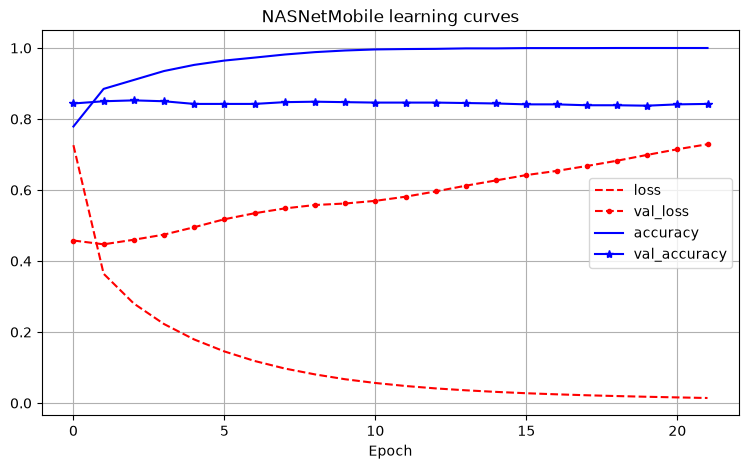

epochs actually run: 22
training time: 94 s
best epoch (weights restored from here): 2
  training loss: 0.3642
  validation loss: 0.4471
  training accuracy: 0.8849
  validation accuracy: 0.8500


In [40]:
pd.DataFrame(history_nasnet.history)[["loss", "val_loss", "accuracy", "val_accuracy"]].plot(
    figsize=(9, 5), grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"],
    title="NASNetMobile learning curves")
plt.show()

print(f"epochs actually run: {len(history['loss'])}")
print(f"training time: {nasnet_time:.0f} s")
print(f"best epoch (weights restored from here): {best_epoch + 1}")
print(f"  training loss: {history['loss'][best_epoch]:.4f}")
print(f"  validation loss: {history['val_loss'][best_epoch]:.4f}")
print(f"  training accuracy: {history['accuracy'][best_epoch]:.4f}")
print(f"  validation accuracy: {history['val_accuracy'][best_epoch]:.4f}")

The learning curves show mild overfitting, which can be seen in the validation loss drifing up while the training loss falls as the number of epochs go by. The training accuracy ends around 88% aginst 85% for validation accuracy. The validation accuracy line remains largely flat while the training accuracy continues to rise to 1.0.

Let's now save the model and take a look at the NASNetMobile's overall performance.

In [41]:
model_nasnet.save(NASNET_FILE)

nasnet_valid_acc = model_nasnet.evaluate(X_valid, y_valid, verbose=0)[1]
nasnet_test_acc = model_nasnet.evaluate(X_test, y_test, verbose=0)[1]

print(f"NASNetMobile validation accuracy: {nasnet_valid_acc:.4f}")
print(f"NASNetMobile test accuracy: {nasnet_test_acc:.4f}")

I0813 20:10:42.738386  518093 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



NASNetMobile validation accuracy: 0.8500
NASNetMobile test accuracy: 0.8540


I0813 20:10:47.662012  518090 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



## Section 4: Comparisons

### Section 4.1: Load Models and Preliminary Report

First, to make this project rerunnable, we need to load model weights from disk.

In [42]:
model_cnn = tf.keras.models.load_model(CNN_FILE)
model_nasnet = tf.keras.models.load_model(NASNET_FILE)

y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)
y_pred_nasnet = np.argmax(model_nasnet.predict(X_test, verbose=0), axis=1)

/home/lingwei/miniconda3/envs/tf-2.20-gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 27 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0813 20:10:57.507178  518092 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads

I0813 20:11:05.941504  518092 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



In [43]:
print(f"CNN test accuracy: {accuracy_score(y_test, y_pred_cnn):.4f}")
print(f"NASNetMobile test accuracy: {accuracy_score(y_test, y_pred_nasnet):.4f}")

print(f"CNN tuning time: {tuning_time:.0f} s")
print(f"NASNetMobile training time: {nasnet_time:.0f} s")

CNN test accuracy: 0.5500
NASNetMobile test accuracy: 0.8540
CNN tuning time: 2887 s
NASNetMobile training time: 94 s


CNN hyperparameter tuning (15 trials @ up to 120 epochs): 2887 s (~48 mins)
NASNetMobile training (22 epochs early stopping): 88 s (~1.5 mins)

The CNN hyperparameter tuning (which automatically gives us the parameter weights for the best model) took ~32 times longer than the NASNetMobile fine tuning. This comparison however is not entirely valid, as hyperparameter tuning covers 15 separate models up to 120 epochs, while NASNetMobile was trained only once to 22 epochs (albeit with ~3.5x more parameters).

The pretrained model is both cheaper to train and performs signifiantly better (0.85 vs 0.55 accuracy), however, the hyperparameter tuning for NASNetMobile would still have been done by someone else using their computing resources, so overall, the NASNetMobile fine tuned model isn't necessarily cheaper. But again, this is one of the advanges of transfer learning, where a pretrained model can be adapted to various tasks, not just this image classification task.

### Section 4.2: Model Complexity

In [44]:
def count_trainable(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))

def count_all(model):
    return int(model.count_params())

pd.DataFrame([
    {"model": "CNN", "trainable params": count_trainable(model_cnn),
     "total params": count_all(model_cnn)},
    {"model": "NASNetMobile", "trainable params": count_trainable(model_nasnet),
     "total params": count_all(model_nasnet)},
]).set_index("model")

,trainable params,total params
model,,
CNN,23130,23130
NASNetMobile,85370,4355086


Evidently, the higher performing model has significantly more parameters (higher complexity) as expected.

### Section 4.3: Per-Class Precision, Recall and F1

In [57]:
metrics = ["precision", "recall", "f1-score"]
rows = class_names + ["Overall"]

def model_report(y_pred):
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    report["Overall"] = report["weighted avg"]
    return pd.DataFrame(report).T.loc[rows, metrics]

comparison = pd.concat({"CNN": model_report(y_pred_cnn), "NASNetMobile": model_report(y_pred_nasnet)}, axis=1)
comparison.round(3)

CNN                 NASNetMobile                
          precision recall f1-score    precision recall f1-score
alligator     0.363   0.74    0.487        0.776  0.760    0.768
dragonfly     0.574   0.62    0.596        0.758  0.940    0.839
dugong        0.932   0.82    0.872        0.980  0.980    0.980
goldfish      0.909   0.80    0.851        0.917  0.880    0.898
goose         0.395   0.64    0.489        0.957  0.880    0.917
koala         0.740   0.74    0.740        0.961  0.980    0.970
scorpion      0.462   0.36    0.404        0.800  0.880    0.838
slug          0.400   0.16    0.229        0.830  0.780    0.804
snail         0.320   0.16    0.213        0.868  0.660    0.750
tarantula     0.561   0.46    0.505        0.741  0.800    0.769
Overall       0.566   0.55    0.539        0.859  0.854    0.853

### Section 4.4: Confusion Matrices

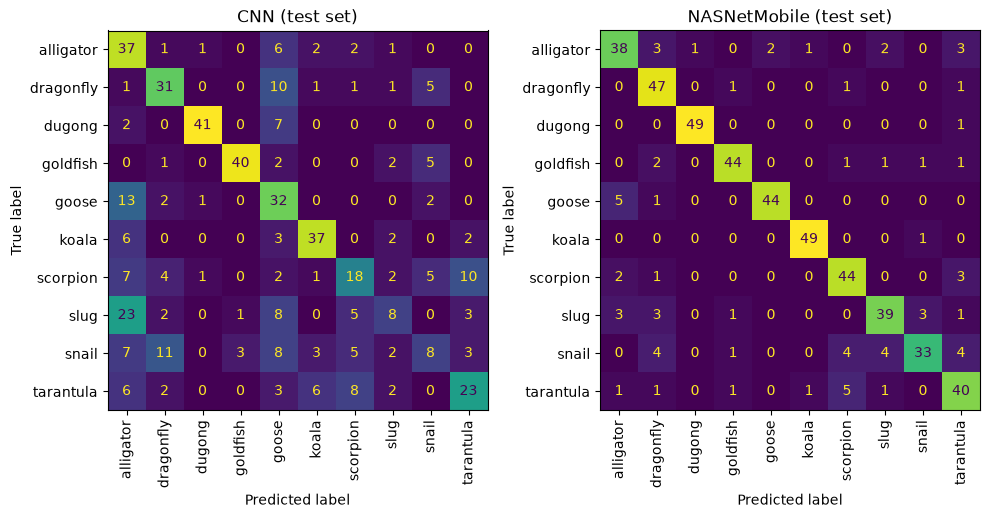

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, y_pred, name in [(axes[0], y_pred_cnn, "CNN"), (axes[1], y_pred_nasnet, "NASNetMobile")]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=class_names, ax=ax, colorbar=False, xticks_rotation="vertical")
    ax.set_title(f"{name} (test set)")
plt.tight_layout()
plt.show()

### Section 4.5: Model Comparison on Instances

In [49]:
# choice: for the two groups where the models disagree the caption shows the prediction
# of the model that got it wrong; for "both incorrect" it shows the CNN's prediction
cnn_correct = y_pred_cnn == y_test
nasnet_correct = y_pred_nasnet == y_test

groups = {
    "both correct": np.where(cnn_correct & nasnet_correct)[0],
    "both incorrect": np.where(~cnn_correct & ~nasnet_correct)[0],
    "CNN correct, NASNetMobile incorrect": np.where(cnn_correct & ~nasnet_correct)[0],
    "NASNetMobile correct, CNN incorrect": np.where(~cnn_correct & nasnet_correct)[0],
}

pd.DataFrame([{"group": name, "number of test images": len(idx)}
              for name, idx in groups.items()]).set_index("group")

,number of test images
group,
both correct,251
both incorrect,49
"CNN correct, NASNetMobile incorrect",24
"NASNetMobile correct, CNN incorrect",176


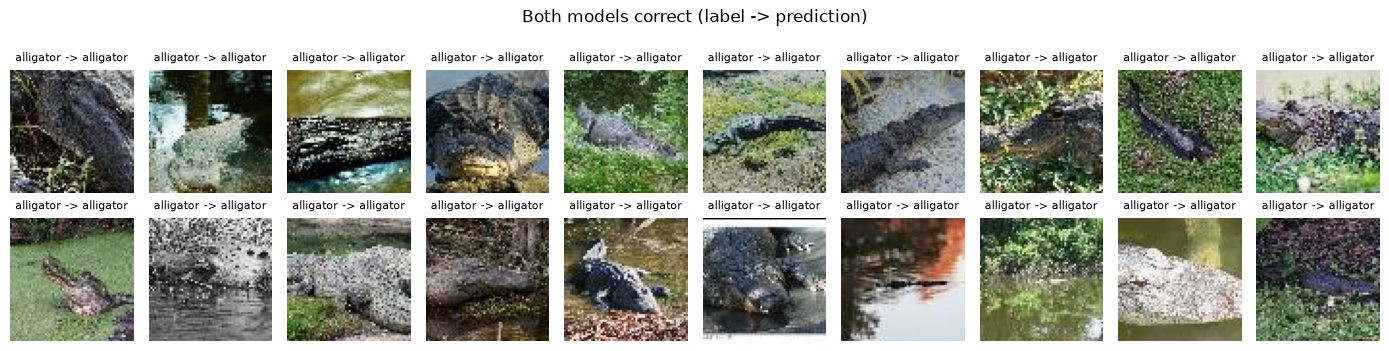

In [50]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["both correct"], y_pred=y_pred_cnn,
               title="Both models correct (label -> prediction)")

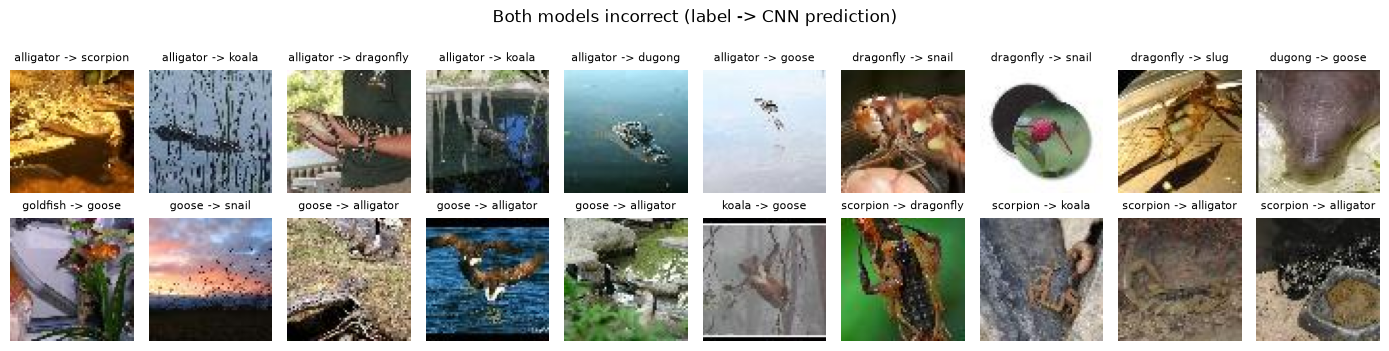

In [51]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["both incorrect"], y_pred=y_pred_cnn,
               title="Both models incorrect (label -> CNN prediction)")

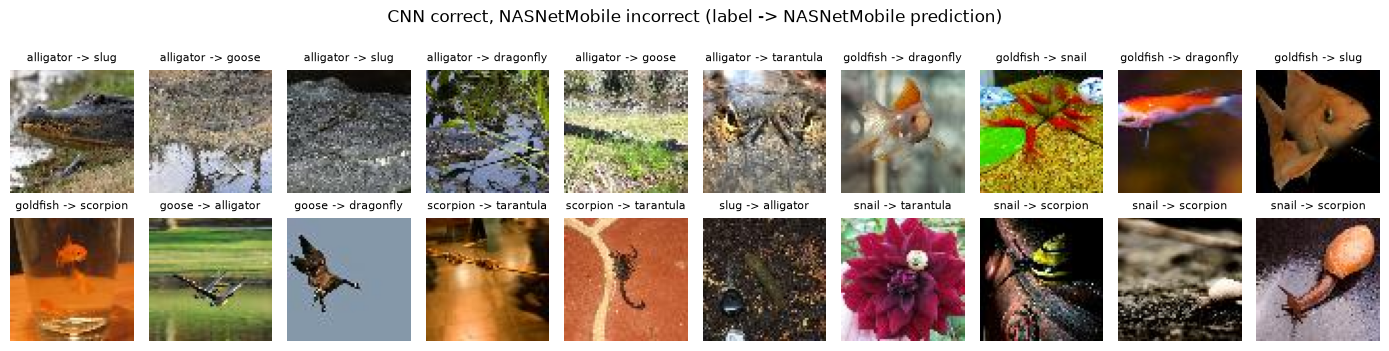

In [ ]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["CNN correct, NASNetMobile incorrect"],
               y_pred=y_pred_nasnet,
               title="CNN correct, NASNetMobile incorrect (label -> NASNetMobile prediction)")

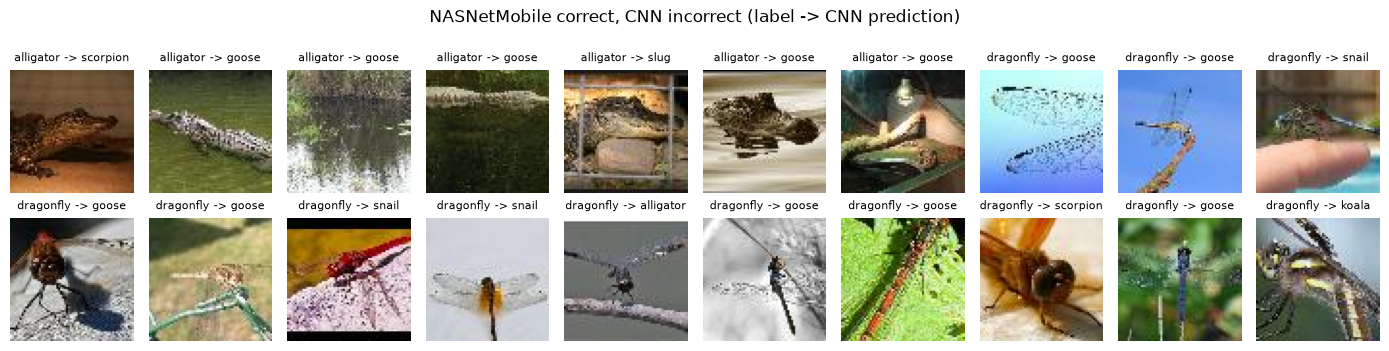

In [53]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["NASNetMobile correct, CNN incorrect"],
               y_pred=y_pred_cnn,
               title="NASNetMobile correct, CNN incorrect (label -> CNN prediction)")

### Section 4.6 Summary and Conclusion

This project compared a small CNN trained from scratch against a frozen, pretrained
NASNetMobile on a 10-class, 3,700-image dataset.

**Results.** The tuned CNN reached **53.6%** test accuracy with 23,130 trainable parameters,
clearing the 50% the specification asks for. NASNetMobile reached **86.8%** with 85,370
trainable parameters in its head, on top of 4.27 million frozen ImageNet parameters. That is
a 33 point gap.

**Where the gap comes from.** Per-class F1 shows the CNN is not uniformly weak. It handles
the visually distinctive classes reasonably well: dugong 0.872 and goldfish 0.839 are close
to NASNetMobile's 0.970 and 0.929. It collapses on the classes that need fine texture and
shape detail, scoring 0.185 on slug, 0.267 on snail and 0.308 on scorpion, which are exactly
the classes where NASNetMobile gains most (+0.636, +0.515 and +0.522 respectively). At
64x64 with four convolutional layers and at most 40 filters, the CNN can pick up colour and
coarse shape but not the texture that separates a slug from a snail. The confusion matrix
backs this up: the CNN's errors cluster among alligator, slug, snail and scorpion, and its
high recall but low precision on alligator (0.780 recall against 0.351 precision) shows it
is using alligator as a catch-all for green and brown textures.

**Agreement.** Both models were right on 249 of the 500 test images and both wrong on 47.
NASNetMobile alone was right on 185, while the CNN alone was right on just 19. So
NASNetMobile does not merely score higher, it almost entirely subsumes what the CNN gets
right. The 47 images both models miss are the genuinely hard ones: heavily cropped, cluttered
or ambiguous.

**Fitting behaviour.** The two models fail differently. The CNN's training accuracy (53.5%)
is essentially the same as its validation accuracy (55.3%), so it is not overfitting at all,
it is capacity-limited, and the augmentation and dropout layers are doing their job.
NASNetMobile sits at 92.0% training against 85.3% validation, so it does mildly overfit, and
early stopping is what keeps that in check.

**Conclusion.** With only 370 training images per class, reusing ImageNet features is worth
far more than architecture search on a small network. The 30,000 parameter budget is the
binding constraint on the CNN, not the tuning: the search space was capped so every candidate
stayed under it, and the best model found used 23,130 parameters, so the tuner was not simply
starved of capacity within the space it was given. The practical lesson is that on a small
dataset the cheapest large gain comes from transfer learning, not from tuning a small model
harder.